# Institution Analysis

**Which institutions contributed the most papers to the selected 292-work corpus?**

This analysis ranks the authors' affiliated universities, research organizations,
companies, and other institutions. These are author affiliations, not journal publishers
or organizations merely mentioned in a paper. Each distinct paper counts **once per
institution**, regardless of how many coauthors share that affiliation. Collaborative
papers count for each participating institution, so counts and shares can sum to more
than 292 and 100%. Equal counts receive equal ranks (competition ranking: 1, 2, 2, 4).

The input is the existing **292 canonical works** in the thesis corpus, after the
project's duplicate-version consolidation. It does not use the larger abstract corpus.
Affiliations come from saved OpenAlex work-level authorships, supplemented by reviewed
PDF affiliation statements, raw affiliations, and explicitly linked sources. Current
affiliations are not substituted for historical paper affiliations. Some supplementary
evidence refers to a different version of the same paper; this is noted in the audit.

Institutions are grouped by OpenAlex ID, with explicit local IDs for organizations
absent from the saved registry. Named university departments/business schools are
assigned to their university; the three INSEAD campus IDs are combined into one school.
Separate OpenAlex entities are otherwise retained, without
automatically adding parent organizations or merging research networks into universities.
This is an initial **metadata-based affiliation ranking**, not an exhaustive manual
verification of every affiliation in all 292 PDFs. Complete paper coverage does not
guarantee that the source metadata captures every secondary affiliation.

Run all cells with **Python (batill)**. Execution is offline and saves the ranking,
paper details, author evidence, and chart under `reports/institution_analysis/`, plus
an Excel workbook named **Institution Analysis.xlsx** in the project root. The cluster
section reuses the saved five-cluster **PDF embedding Leiden** solution, showing where
each institution's papers fall. Graphs display institutions with at least 12 papers;
exported tables retain every institution.

In [1]:
from pathlib import Path
from collections import defaultdict
import hashlib
import json
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.worksheet.table import Table, TableStyleInfo
from openpyxl.formatting.rule import DataBarRule
from openpyxl.formatting.rule import ColorScaleRule
from openpyxl.utils import get_column_letter

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'reports/thesis_v2/evidence/corpus.csv').exists())
GRAPH = ROOT / 'outputs/citation_graph_openalex/9ad47e071ee12c2f'
CORPUS_PATH = ROOT / 'reports/thesis_v2/evidence/corpus.csv'
NODES_PATH = GRAPH / 'reviewed/nodes.csv'
WORKS_PATH = GRAPH / 'resolved_works.json'
SUPPLEMENTS_PATH = ROOT / 'configs/institution_affiliation_supplements.json'
OUTPUT = ROOT / 'reports/institution_analysis'
OUTPUT.mkdir(parents=True, exist_ok=True)
EXCEL_PATH = ROOT / 'Institution Analysis.xlsx'
EXPECTED_PAPERS = 292
MIN_PAPERS_FOR_PLOTS = 12
source_files = {CORPUS_PATH, NODES_PATH, WORKS_PATH, SUPPLEMENTS_PATH}

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

def relative(path):
    return str(Path(path).relative_to(ROOT))

corpus = pd.read_csv(CORPUS_PATH, keep_default_na=False)
nodes = pd.read_csv(NODES_PATH, keep_default_na=False)
assert len(corpus) == EXPECTED_PAPERS
assert corpus.paper_id.is_unique and corpus.pdf_sha256.is_unique
assert nodes.Key.is_unique and nodes.openalex_id.is_unique
papers = corpus[['paper_id', 'pdf_sha256', 'title', 'source_filename']].merge(
    nodes[['Key', 'paper_id', 'openalex_id', 'openalex_year', 'openalex_doi']],
    left_on=['pdf_sha256', 'paper_id'], right_on=['Key', 'paper_id'],
    how='left', validate='one_to_one', indicator=True)
assert papers['_merge'].eq('both').all(), 'Every paper must have reviewed identity metadata'
papers = papers.drop(columns=['Key', '_merge'])

resolved = json.loads(WORKS_PATH.read_text())
work_records = {}
work_sources = {}
identity_corrections = []
# Reviewed work IDs take precedence over stale records indexed by PDF hash.
for row in papers.itertuples(index=False):
    work = resolved.get(row.pdf_sha256, {})
    if work.get('id') == row.openalex_id:
        work_records[row.paper_id] = work
        work_sources[row.paper_id] = relative(WORKS_PATH)
        continue
    candidates = []
    for path in sorted((GRAPH.parent / 'api_cache').glob('*.json')):
        cached = json.loads(path.read_text())
        for candidate in cached.get('payload', {}).get('results', []):
            if candidate.get('id') == row.openalex_id:
                candidates.append((cached.get('fetched_at_utc', ''), str(path), candidate))
    assert candidates, f'No saved record for reviewed work {row.openalex_id}'
    _, filename, corrected = max(candidates, key=lambda c: (c[0], c[1]))
    path = Path(filename)
    source_files.add(path)
    work_records[row.paper_id] = corrected
    work_sources[row.paper_id] = relative(path)
    identity_corrections.append({'paper_id': row.paper_id,
                                 'stale_id': work.get('id'), 'reviewed_id': row.openalex_id,
                                 'source_path': relative(path)})
assert all(work_records[r.paper_id]['id'] == r.openalex_id
           for r in papers.itertuples(index=False))
print(f'Loaded {len(papers)} canonical papers; corrected {len(identity_corrections)} stale metadata record(s).')

Loaded 292 canonical papers; corrected 1 stale metadata record(s).


## Reviewed additions and affiliation evidence

The editable file `configs/institution_affiliation_supplements.json` records each
reviewed addition with its author, institution, and evidence. It also records independent
researchers and corrections for Warburg Pincus and Northwestern University. PDF evidence is
checked against the saved extraction file and block. External source notes are preserved
for offline reproducibility; no network requests are made when this notebook runs.

P039's US Northwestern affiliation is corroborated by
[Kellogg's report of that study](https://insight.kellogg.northwestern.edu/article/private-equity-helped-firms-weather-the-great-recession).
The INSEAD campus grouping follows its [institutional campus list](https://www.insead.edu/about-insead/campuses).
P244 uses the book's
[contributor biographies](https://api.pageplace.de/preview/DT0400.9781801178006_A45617803/preview-9781801178006_A45617803.pdf)
and [Aimee La France's study-specific research history](https://mgmt.wharton.upenn.edu/profile/aslafran/).
P304 uses the affiliation in the
[Harvard-hosted version of the same study](https://www.hbs.edu/ris/Publication%20Files/ReplicatingPE_201512_3859877f-bd53-4d3e-99aa-6daec2a3a2d3.pdf).

In [2]:
review = json.loads(SUPPLEMENTS_PATH.read_text())
campus_groups = {iid: group for group in review.get('institution_groups', [])
                 for iid in group['member_ids']}

def normalize_institution(institution):
    normalized = dict(campus_groups.get(institution['id'], institution))
    normalized['source_institution_id'] = institution['id']
    return normalized

supplements = {(s['paper_id'], s['author_index']): s for s in review['entries']}
assert len(supplements) == len(review['entries']), 'Duplicate author review'
used_supplements = set()
evidence_rows, author_rows = [], []
registry = {}

for paper in papers.to_dict('records'):
    pid = paper['paper_id']
    authorships = work_records[pid].get('authorships', [])
    assert authorships, f'No author records: {pid}'
    for index, authorship in enumerate(authorships):
        author = authorship['author']['display_name']
        original = authorship.get('institutions', [])
        raw = '; '.join(authorship.get('raw_affiliation_strings', []))
        supplement = supplements.get((pid, index))
        extra = []
        if supplement:
            used_supplements.add((pid, index))
            assert supplement['pdf_sha256'] == paper['pdf_sha256']
            assert supplement['author_name'] == author, f'Author identity changed: {pid}'
            if supplement.get('source_path'):
                source = ROOT / supplement['source_path']
                source_files.add(source)
                if supplement.get('source_sha256'):
                    assert sha256(source) == supplement['source_sha256']
                    document = json.loads(source.read_text())
                    block = next(b for b in document['blocks'] if b['id'] == supplement['source_block'])
                    assert supplement['evidence'] in block['text']
            extra = supplement['institutions']
        retained = [] if supplement and supplement.get('replace') else original
        retained = [normalize_institution(i) for i in retained]
        extra = [normalize_institution(i) for i in extra]
        for institution, kind in [(i, 'openalex') for i in retained] + [(i, 'reviewed_supplement') for i in extra]:
            iid = institution['id']
            assert iid and institution['display_name']
            registry[iid] = {
                'institution_id': iid, 'institution': institution['display_name'],
                'country_code': institution.get('country_code') or '',
                'institution_type': institution.get('type') or '',
                'ror': institution.get('ror') or ''}
            evidence_rows.append({
                'paper_id': pid, 'title': paper['title'], 'author_index': index,
                'author': author, 'institution_id': iid,
                'institution': institution['display_name'], 'source_kind': kind,
                'source_institution_id': institution['source_institution_id'],
                'source_path_or_url': work_sources[pid] if kind == 'openalex' else
                    supplement.get('source_url', supplement.get('source_path', '')),
                'source_block': supplement.get('source_block', '') if kind != 'openalex' else '',
                'evidence': raw if kind == 'openalex' else supplement['evidence'],
                'note': supplement.get('note', '') if kind != 'openalex' else '',
            })
        assigned = {i['id'] for i in retained + extra}
        status = ('assigned' if assigned else 'independent'
                  if supplement and supplement['status'] == 'independent' else 'unresolved')
        author_rows.append({
            'paper_id': pid, 'author_index': index, 'author': author,
            'openalex_institutions': '; '.join(i['display_name'] for i in original),
            'final_institutions': '; '.join(sorted(registry[i]['institution'] for i in assigned)),
            'status': status, 'reviewed': bool(supplement),
            'raw_affiliations': raw,
            'review_note': supplement.get('note', '') if supplement else '',
        })
assert used_supplements == set(supplements), 'Unused or stale review entry'
evidence = pd.DataFrame(evidence_rows)
author_audit = pd.DataFrame(author_rows)
institutions = pd.DataFrame(registry.values())
# No repetition from multiple authors, multiple affiliations, or duplicate evidence.
pairs = evidence[['paper_id', 'institution_id']].drop_duplicates()
assert not pairs.duplicated(['paper_id', 'institution_id']).any()
assert set(pairs.paper_id) == set(papers.paper_id), 'Paper without an institution'
assert not author_audit.status.eq('unresolved').any(), 'Unresolved author affiliation'
print(f'{len(pairs)} distinct paper–institution links; {len(institutions)} institutions.')
print(f'{author_audit.reviewed.sum()} author records reviewed; '
      f'{author_audit.status.eq("independent").sum()} explicitly independent researchers.')

906 distinct paper–institution links; 277 institutions.
64 author records reviewed; 2 explicitly independent researchers.


## Institutions ranked by number of papers

**Papers** is the number of unique canonical papers associated with the institution.
**Share of 292 (%)** uses all 292 papers as the denominator. The OpenAlex-only and
supplement-only columns show how much the ranking relies on reviewed additions.
Supplement-only counts exclude papers already credited to the same institution by
another author's OpenAlex affiliation. Alphabetical ordering breaks display ties only.

In [3]:
counts = pairs.groupby('institution_id').paper_id.nunique().rename('papers')
oa_counts = (evidence.loc[evidence.source_kind.eq('openalex')]
             .groupby('institution_id').paper_id.nunique().rename('openalex_papers'))
paper_lists = pairs.groupby('institution_id').paper_id.agg(
    lambda values: '; '.join(sorted(set(values)))).rename('paper_ids')
ranking = (institutions.merge(counts, on='institution_id', validate='one_to_one')
           .merge(oa_counts, on='institution_id', how='left', validate='one_to_one')
           .merge(paper_lists, on='institution_id', validate='one_to_one'))
ranking['openalex_papers'] = ranking.openalex_papers.fillna(0).astype(int)
ranking['supplement_only_papers'] = ranking.papers - ranking.openalex_papers
ranking['share_of_292_pct'] = ranking.papers / EXPECTED_PAPERS * 100
ranking['rank'] = ranking.papers.rank(method='min', ascending=False).astype(int)
ranking = ranking.sort_values(['papers', 'institution'], ascending=[False, True]).reset_index(drop=True)
ranking = ranking[['rank', 'institution', 'papers', 'share_of_292_pct', 'country_code',
                   'institution_type', 'openalex_papers', 'supplement_only_papers',
                   'paper_ids', 'institution_id', 'ror']]
paper_institutions = pairs.merge(institutions, on='institution_id', validate='many_to_one')
paper_details = papers.merge(
    paper_institutions.groupby('paper_id').agg(
        institution_count=('institution_id', 'nunique'),
        institutions=('institution', lambda v: '; '.join(sorted(set(v))))),
    on='paper_id', validate='one_to_one')
paper_details = paper_details.merge(
    author_audit.groupby('paper_id').agg(
        author_count=('author_index', 'size'), reviewed_authors=('reviewed', 'sum'),
        independent_authors=('status', lambda v: int(v.eq('independent').sum()))),
    on='paper_id', validate='one_to_one')
display_columns = ['rank', 'institution', 'papers', 'share_of_292_pct', 'country_code', 'institution_type']
display(HTML(ranking[display_columns].to_html(index=False, float_format=lambda x: f'{x:.2f}')))

rank,institution,papers,share_of_292_pct,country_code,institution_type
1,National Bureau of Economic Research,56,19.18,US,nonprofit
2,Harvard University,44,15.07,US,education
3,University of Chicago,33,11.30,US,education
4,University of Oxford,28,9.59,GB,education
5,Centre for Economic Policy Research,20,6.85,GB,nonprofit
6,European Corporate Governance Institute,16,5.48,BE,nonprofit
6,Stanford University,16,5.48,US,education
8,Columbia University,15,5.14,US,education
9,Massachusetts Institute of Technology,12,4.11,US,education
9,The Ohio State University,12,4.11,US,education


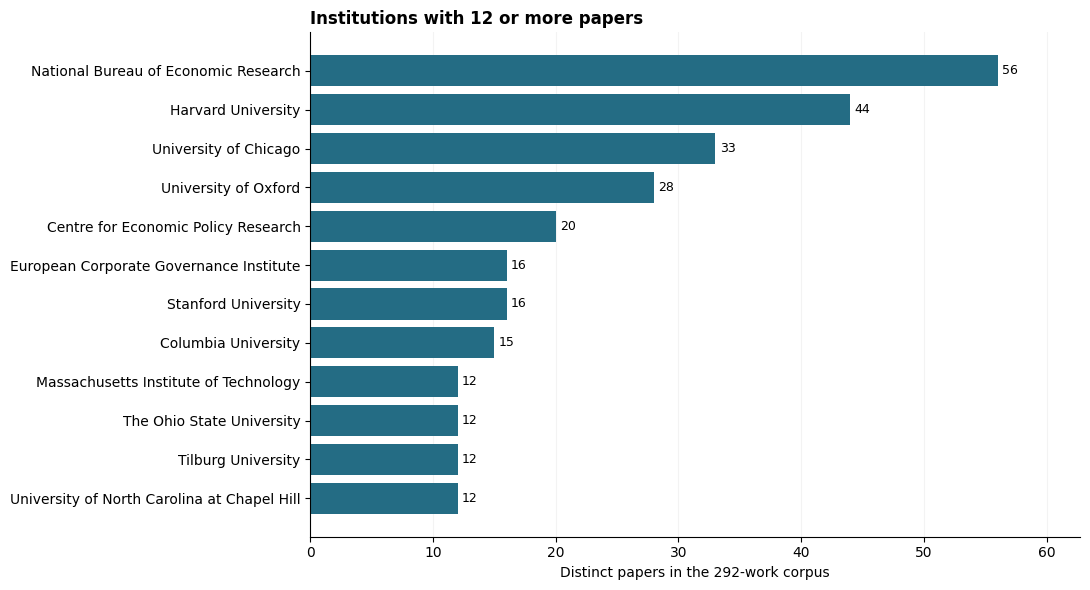

In [4]:
top = ranking.loc[ranking.papers >= MIN_PAPERS_FOR_PLOTS].iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top.institution, top.papers, color='#246C84')
for y, value in enumerate(top.papers):
    ax.text(value + 0.35, y, str(value), va='center', fontsize=9)
ax.set_xlim(0, top.papers.max() * 1.12)
ax.set_xlabel('Distinct papers in the 292-work corpus')
ax.set_title(f'Institutions with {MIN_PAPERS_FOR_PLOTS} or more papers', loc='left', weight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.15)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(OUTPUT / 'institutions_12_or_more_papers.png', dpi=180, bbox_inches='tight')
fig.savefig(OUTPUT / 'institutions_12_or_more_papers.pdf', bbox_inches='tight')
plt.show()

## Institution distribution across the five embedding Leiden clusters

This section reuses **the saved PDF embedding Leiden solution** from
`Clustering PDFs.ipynb`: resolution **0.95**, retained seed **44**, five clusters,
and exactly the same **292 canonical PDFs**. The saved memberships are joined by
both paper ID and PDF hash. No clustering is rerun. The existing cluster IDs
**L1–L5** and their provisional topic names are preserved.

Each institution's paper count is split across the five clusters. A paper counts
once for each affiliated institution, and belongs to exactly one cluster.
Consequently, an institution's five counts add to its overall paper count.
The five percentages use **that institution's total papers** as the denominator
and add to 100%. For example, 10 of an institution's 20 papers in L4 means 50%.
These percentages are not the institution's share of the entire cluster.

The graph and displayed institution table retain the **12-paper minimum**.
Cluster Counts and Cluster Shares in Excel/CSV include **all institutions**,
including zero counts for clusters where an institution has no papers.
Cluster sizes differ, so concentration in a large cluster alone is not evidence
of specialization; the cluster summary provides the corpus-wide baseline.

In [5]:
CLUSTER_SOLUTION = 'embedding_leiden_k5'
CLUSTER_CONFIG_PATH = ROOT / 'configs/topic-age-inputs.json'
PARTITION_DIR = ROOT / 'outputs/pdf_text_clusters/d4437a4c2460707a/five_clusters'
PARTITION_PATH = PARTITION_DIR / 'partition_manifest.json'
ASSIGNMENTS_PATH = PARTITION_DIR / 'assignments.csv'
cluster_config = json.loads(CLUSTER_CONFIG_PATH.read_text())['sources']['pdfs']
partition = json.loads(PARTITION_PATH.read_text())
cluster_settings = partition['solutions'][CLUSTER_SOLUTION]
assert partition['source_kind'] == 'pdf_text_embeddings'
assert cluster_settings['k'] == 5 and cluster_settings['papers'] == EXPECTED_PAPERS
assert np.isclose(cluster_settings['resolution'], 0.95)
assert sha256(ASSIGNMENTS_PATH) == partition['assignments_sha256']
source_files.update([CLUSTER_CONFIG_PATH, PARTITION_PATH, ASSIGNMENTS_PATH])

def read_frozen_cluster_table(spec):
    path = ROOT / spec['path']
    assert sha256(path) == spec['sha256'], f'Cluster source changed: {path}'
    source_files.add(path)
    frame = pd.read_csv(path, keep_default_na=False)
    return frame.loc[frame.solution.eq(CLUSTER_SOLUTION)].copy()

members = read_frozen_cluster_table(cluster_config['memberships'])
profiles = read_frozen_cluster_table(cluster_config['profiles'])
assignments = pd.read_csv(ASSIGNMENTS_PATH, keep_default_na=False)
assignments = assignments.loc[assignments.solution.eq(CLUSTER_SOLUTION)]
identity_columns = ['paper_id', 'pdf_sha256']
assert len(members) == EXPECTED_PAPERS
assert members.paper_id.is_unique and members.pdf_sha256.is_unique
assert len(assignments) == EXPECTED_PAPERS and assignments.paper_id.is_unique
assert assignments.pdf_sha256.is_unique
assert set(members.cluster) == set(profiles.cluster) == {1, 2, 3, 4, 5}
assert profiles.cluster.is_unique
assert members.proposal_matched.eq(True).all() and profiles.proposal_matched.eq(True).all()
assert set(map(tuple, members[identity_columns].to_numpy())) == set(
    map(tuple, papers[identity_columns].to_numpy())), 'Cluster corpus differs from institution corpus'
pd.testing.assert_frame_equal(
    members[identity_columns + ['cluster']].sort_values('paper_id').reset_index(drop=True),
    assignments[identity_columns + ['cluster']].sort_values('paper_id').reset_index(drop=True))

cluster_summary = profiles[['cluster', 'display_cluster', 'proposed_label', 'papers',
                            'status', 'review_caveat']].rename(
    columns={'proposed_label': 'topic_name', 'papers': 'cluster_papers'}).sort_values('cluster')
cluster_summary['corpus_share_pct'] = cluster_summary.cluster_papers / EXPECTED_PAPERS * 100
actual_sizes = members.groupby('cluster').size()
assert actual_sizes.to_dict() == cluster_summary.set_index('cluster').cluster_papers.to_dict()
assert members.groupby('cluster').proposed_label.nunique().eq(1).all()
assert members.groupby('cluster').proposed_label.first().to_dict() == (
    cluster_summary.set_index('cluster').topic_name.to_dict())
cluster_papers = paper_details.merge(
    members[identity_columns + ['cluster']], on=identity_columns,
    how='left', validate='one_to_one').merge(
    cluster_summary[['cluster', 'display_cluster', 'topic_name']],
    on='cluster', how='left', validate='many_to_one')
assert len(cluster_papers) == EXPECTED_PAPERS and cluster_papers.cluster.notna().all()
cluster_institution_papers = paper_institutions.merge(
    cluster_papers[['paper_id', 'pdf_sha256', 'title', 'cluster', 'display_cluster', 'topic_name']],
    on='paper_id', how='left', validate='many_to_one')
assert len(cluster_institution_papers) == len(pairs)
assert not cluster_institution_papers.duplicated(['institution_id', 'paper_id']).any()

cluster_labels = cluster_summary.display_cluster.tolist()
count_matrix = (cluster_institution_papers.groupby(['institution_id', 'display_cluster'])
                .paper_id.nunique().unstack(fill_value=0)
                .reindex(index=ranking.institution_id, columns=cluster_labels, fill_value=0))
totals = ranking.set_index('institution_id').papers
assert count_matrix.sum(axis=1).eq(totals).all()
share_matrix = count_matrix.div(totals, axis=0) * 100
assert np.allclose(share_matrix.sum(axis=1), 100)
institution_meta = ranking[['rank', 'institution', 'papers', 'institution_id']].rename(
    columns={'papers': 'total_papers'})
cluster_counts = institution_meta.merge(count_matrix.reset_index(), on='institution_id', validate='one_to_one')
cluster_shares = institution_meta.merge(share_matrix.reset_index(), on='institution_id', validate='one_to_one')
plot_institution_ids = ranking.loc[ranking.papers.ge(MIN_PAPERS_FOR_PLOTS), 'institution_id'].tolist()
display(HTML(cluster_summary[['display_cluster', 'topic_name', 'cluster_papers', 'corpus_share_pct']]
             .to_html(index=False, float_format=lambda x: f'{x:.1f}')))
print(f'Paper counts by cluster — institutions with at least {MIN_PAPERS_FOR_PLOTS} papers:')
display(HTML(cluster_counts.loc[cluster_counts.institution_id.isin(plot_institution_ids),
                                ['institution', 'total_papers'] + cluster_labels].to_html(index=False)))

display_cluster,topic_name,cluster_papers,corpus_share_pct
L1,"Portfolio-company performance, employment and governance",73,25.0
L2,"Leveraged buyout transactions, financing and value creation",62,21.2
L3,"Public/private ownership, listing and financing theory (mixed)",31,10.6
L4,"Private equity fund performance, fundraising and investors",97,33.2
L5,"Private equity in healthcare: ownership, costs and quality",29,9.9


Paper counts by cluster — institutions with at least 12 papers:


institution,total_papers,L1,L2,L3,L4,L5
National Bureau of Economic Research,56,14,7,4,28,3
Harvard University,44,15,6,2,14,7
University of Chicago,33,7,7,2,14,3
University of Oxford,28,3,4,1,19,1
Centre for Economic Policy Research,20,4,5,3,8,0
European Corporate Governance Institute,16,6,1,4,5,0
Stanford University,16,5,0,2,8,1
Columbia University,15,3,1,1,7,3
Massachusetts Institute of Technology,12,3,4,0,4,1
The Ohio State University,12,1,4,1,6,0


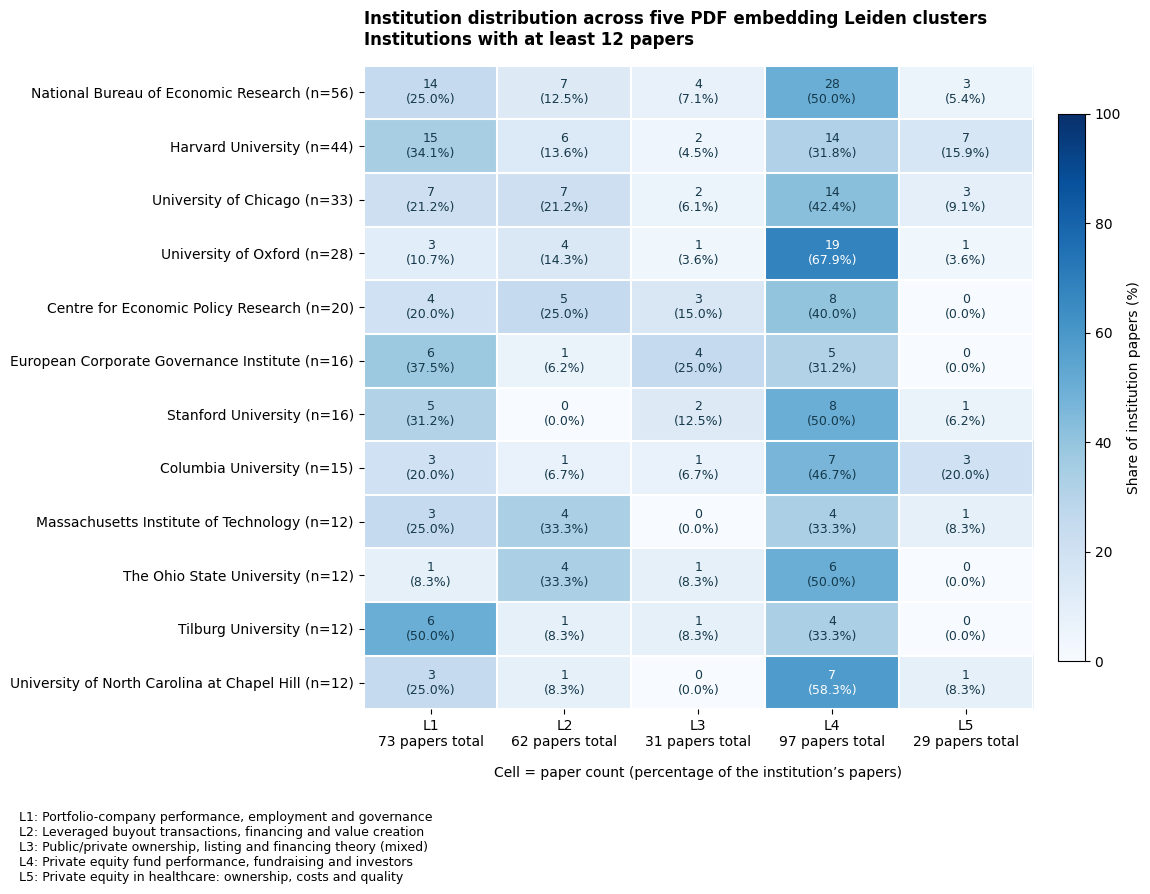

In [6]:
plot_counts = count_matrix.loc[plot_institution_ids]
plot_shares = share_matrix.loc[plot_institution_ids]
plot_names = ranking.set_index('institution_id').loc[plot_institution_ids, 'institution']
row_labels = [f'{name} (n={totals.loc[iid]})' for iid, name in plot_names.items()]
fig, ax = plt.subplots(figsize=(12, max(5, 0.5 * len(plot_counts) + 2)))
heatmap = ax.imshow(plot_shares.to_numpy(), cmap='Blues', vmin=0, vmax=100, aspect='auto')
ax.set_yticks(range(len(row_labels)), row_labels)
cluster_sizes = cluster_summary.set_index('display_cluster').cluster_papers
ax.set_xticks(range(len(cluster_labels)),
              [f'{label}\n{cluster_sizes[label]} papers total' for label in cluster_labels])
ax.set_title('Institution distribution across five PDF embedding Leiden clusters\n'
             f'Institutions with at least {MIN_PAPERS_FOR_PLOTS} papers', loc='left', pad=15, weight='bold')
ax.set_xlabel('Cell = paper count (percentage of the institution’s papers)', labelpad=12)
for row in range(len(plot_counts)):
    for col in range(len(cluster_labels)):
        count = int(plot_counts.iloc[row, col])
        share = float(plot_shares.iloc[row, col])
        ax.text(col, row, f'{count}\n({share:.1f}%)', ha='center', va='center',
                color='white' if share >= 55 else '#15394A', fontsize=9)
ax.set_xticks(np.arange(-0.5, len(cluster_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(row_labels), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)
colorbar = fig.colorbar(heatmap, ax=ax, pad=0.03, shrink=0.85)
colorbar.set_label('Share of institution papers (%)')
fig.tight_layout()
topic_key = '\n'.join(f'{r.display_cluster}: {r.topic_name}'
                      for r in cluster_summary.itertuples(index=False))
fig.text(0.02, -0.02, topic_key, ha='left', va='top', fontsize=9)
fig.savefig(OUTPUT / 'institution_leiden_cluster_distribution.png', dpi=180, bbox_inches='tight')
fig.savefig(OUTPUT / 'institution_leiden_cluster_distribution.pdf', bbox_inches='tight')
plt.show()

## Paper details, coverage, and exports

All 292 papers remain in the paper table. Use `paper_details`, `paper_institutions`,
`evidence`, and `author_audit` to trace any count to a paper and an affiliation source.
The Excel workbook opens on the complete institution ranking; its other tabs contain
the full paper list, distinct paper–institution links, author evidence, review records,
and counting rules. The cluster tabs provide counts, within-institution percentages,
cluster definitions, and paper-level memberships. Filter the institution column to
inspect a particular organization.

In [7]:
summary = {
    'Canonical papers': len(papers),
    'Papers with at least one institution': pairs.paper_id.nunique(),
    'Institutions': len(ranking),
    'Distinct paper–institution links': len(pairs),
    'Reviewed author records': int(author_audit.reviewed.sum()),
    'Papers with reviewed author records': author_audit.loc[author_audit.reviewed, 'paper_id'].nunique(),
    'Explicitly independent author records': int(author_audit.status.eq('independent').sum()),
    'Unresolved author records': int(author_audit.status.eq('unresolved').sum()),
}
display(pd.DataFrame(summary.items(), columns=['Measure', 'Value']))
display(paper_details[['paper_id', 'title', 'institution_count', 'institutions']].head(15))
reviews = pd.DataFrame([{
    'paper_id': s['paper_id'], 'author': s['author_name'], 'status': s['status'],
    'institutions': '; '.join(i['display_name'] for i in s['institutions']),
    'replaces_openalex': s.get('replace', False), 'source_kind': s['source_kind'],
    'source_path_or_url': s.get('source_url', s.get('source_path', '')),
    'source_block': s.get('source_block', ''), 'evidence': s['evidence'],
    'note': s.get('note', '')} for s in review['entries']])
methods = pd.DataFrame([
    ('Title', 'Institution Analysis'),
    ('Scope', 'The existing 292 canonical works in reports/thesis_v2/evidence/corpus.csv.'),
    ('Institution meaning', 'Author-affiliated universities, research institutes, companies, and other organizations; not journal publishers.'),
    ('Count', 'One count per distinct paper and institution. Multiple coauthors at one institution count once. Multi-institution papers count for every institution.'),
    ('Ranks', 'Descending paper count; ties share competition rank. Alphabetical display within ties.'),
    ('Share denominator', '292 papers. Shares and counts across institutions are not additive to 100% or 292.'),
    ('Institution identity', 'OpenAlex IDs where available; local: IDs identify manually normalized organizations. INSEAD campuses are grouped into one school with deduplicated papers; original source IDs remain in the evidence. No automatic parent-lineage expansion.'),
    ('Source', 'Saved reviewed OpenAlex work identities and work-level author affiliations, with reviewed source-linked supplements.'),
    ('Versions', 'Supplementary PDF affiliations may describe the local version, while OpenAlex describes the reviewed publication. P304 uses an earlier working-paper affiliation for the same study. See evidence notes.'),
    ('Independent authors', 'Explicitly independent researchers are audited but not counted as institutions.'),
    ('Coverage limitation', 'All papers have an institution and all author records have an affiliation assignment or explicit independent status. This does not establish exhaustive secondary affiliations or validate every OpenAlex match.'),
    ('Country/type', 'Descriptive metadata from the saved institution record or reviewed supplement; institutions can operate across countries.'),
    ('Supplement configuration', relative(SUPPLEMENTS_PATH)),
    ('Review date', review['review_date']),
    ('Cluster source', f'Saved PDF embedding Leiden: resolution {cluster_settings["resolution"]}, seed {cluster_settings["seed"]}, solution {CLUSTER_SOLUTION}. Memberships are reused without refitting.'),
    ('Cluster percentages', 'Each cluster count divided by that institution’s total paper count, times 100. Each institution’s row sums to 100%; these are not shares of the cluster.'),
    ('Cluster comparison', 'Cluster sizes differ. Corpus-share baseline is in Cluster Summary; raw concentration alone is not evidence of specialization. Topic names remain provisional.'),
    ('Graph filter', f'Institutions with at least {MIN_PAPERS_FOR_PLOTS} papers overall; all institutions remain in cluster tables.'),
] + [(key, str(value)) for key, value in summary.items()], columns=['Field', 'Value'])

groups = pd.DataFrame([{
    'institution': g['display_name'], 'institution_id': g['id'],
    'source_institution_ids': '; '.join(g['member_ids']),
    'source_url': g['source_url'], 'note': g['note']}
    for g in review.get('institution_groups', [])])
tables = {'Institution Ranking': ranking,
          'Cluster Counts': cluster_counts, 'Cluster Shares': cluster_shares,
          'Cluster Summary': cluster_summary, 'Cluster Papers': cluster_papers,
          'Cluster Institution Papers': cluster_institution_papers,
          'Papers': paper_details,
          'Paper Institutions': paper_institutions, 'Affiliation Evidence': evidence,
          'Author Audit': author_audit, 'Reviewed Additions': reviews,
          'Institution Groups': groups, 'Methods': methods}
csv_paths = []
for name, frame in tables.items():
    path = OUTPUT / (name.lower().replace(' ', '_') + '.csv')
    frame.to_csv(path, index=False)
    csv_paths.append(path)
with pd.ExcelWriter(EXCEL_PATH, engine='openpyxl') as writer:
    for name, frame in tables.items():
        frame.to_excel(writer, sheet_name=name, index=False)
        ws = writer.sheets[name]
        ws.freeze_panes = 'C2' if name == 'Institution Ranking' else 'B2'
        ws.sheet_view.showGridLines = False
        for cell in ws[1]:
            cell.font = Font(color='FFFFFF', bold=True)
            cell.fill = PatternFill('solid', fgColor='184C60')
            cell.alignment = Alignment(vertical='center')
        ws.row_dimensions[1].height = 28
        table = Table(displayName=name.replace(' ', ''), ref=ws.dimensions)
        table.tableStyleInfo = TableStyleInfo(name='TableStyleMedium2', showRowStripes=True)
        ws.add_table(table)
        for col, label in enumerate(frame.columns, start=1):
            max_content = max([len(str(label))] + [len(str(v)) for v in frame[label]])
            ws.column_dimensions[get_column_letter(col)].width = min(65, max(14, max_content + 2))
        # Source text is literal text, never an executable spreadsheet formula.
        for row in ws.iter_rows(min_row=2):
            for cell in row:
                if isinstance(cell.value, str):
                    cell.data_type = 's'
        if name == 'Institution Ranking':
            ws.column_dimensions['B'].width = 58
            for cell in ws['D'][1:]:
                cell.number_format = '0.00'
            ws.conditional_formatting.add(f'C2:C{ws.max_row}',
                DataBarRule(start_type='num', start_value=0,
                            end_type='max', color='68AFBC', showValue=True))
        if name == 'Methods':
            ws.column_dimensions['B'].width = 110
            for row in ws.iter_rows(min_row=2):
                row[1].alignment = Alignment(wrap_text=True, vertical='top')
                ws.row_dimensions[row[0].row].height = 45
        if name in ['Cluster Counts', 'Cluster Shares']:
            ws.freeze_panes = 'E2'
            ws.column_dimensions['B'].width = 58
            ws.column_dimensions['D'].hidden = True
            for label in cluster_labels:
                column = get_column_letter(frame.columns.get_loc(label) + 1)
                if name == 'Cluster Shares':
                    for cell in ws[column][1:]:
                        cell.number_format = '0.0"%"'
            if name == 'Cluster Shares':
                first = get_column_letter(frame.columns.get_loc(cluster_labels[0]) + 1)
                last = get_column_letter(frame.columns.get_loc(cluster_labels[-1]) + 1)
                ws.conditional_formatting.add(f'{first}2:{last}{ws.max_row}',
                    ColorScaleRule(start_type='num', start_value=0, start_color='FFFFFF',
                                   end_type='num', end_value=100, end_color='246C84'))
    writer.book.properties.title = 'Institution Analysis'
    writer.book.properties.subject = 'Institution ranking for 292 canonical research papers'
print(f'Saved {relative(EXCEL_PATH)} and {len(csv_paths)} CSV tables.')

,Measure,Value
0,Canonical papers,292
1,Papers with at least one institution,292
2,Institutions,277
3,Distinct paper–institution links,906
4,Reviewed author records,64
5,Papers with reviewed author records,43
6,Explicitly independent author records,2
7,Unresolved author records,0


,paper_id,title,institution_count,institutions
0,P001,ESG Disclosures in the Private Equity Industry,1,London Business School
1,P002,What drives leverage in leveraged buyouts? An ...,2,Erasmus University Rotterdam; Vlerick Business...
2,P003,Corporate governance and value creation: Evide...,8,Centre for Economic Policy Research; European ...
3,P004,"More insiders, more insider trading: Evidence ...",4,Centre for Economic Policy Research; London Bu...
4,P005,Structure and determinants of financial covena...,2,Technical University of Munich; University of ...
5,P006,Private Equity Acquisitions of Continental Eur...,4,Cardiff University; European Corporate Governa...
6,P007,The rise of dual-class stock IPOs *,5,Duke University; National Bureau of Economic R...
7,P008,Private Equity and Workers' Career Paths: The ...,3,London School of Economics and Political Scien...
8,P009,Liquidity Provision in the Secondary Market fo...,6,Boston College; Centre for Economic Policy Res...
9,P010,Private equity in the global economy: Evidence...,2,George Mason University; University of North C...


Saved Institution Analysis.xlsx and 13 CSV tables.


## Reproducibility checks

Checks enforce the exact corpus, reviewed work identity, unique paper–institution
pairs, complete paper coverage, ranks, and the saved workbook contents. Source file
hashes and output hashes are written to `run_manifest.json`. Source records and all
pre-existing analysis outputs are left in place.

In [8]:
assert len(paper_details) == EXPECTED_PAPERS
assert paper_details.paper_id.is_unique
assert paper_details.institution_count.ge(1).all()
assert ranking.papers.is_monotonic_decreasing
assert ranking.papers.between(1, EXPECTED_PAPERS).all()
assert ranking.institution_id.is_unique
assert ranking.papers.sum() == len(pairs)
assert ranking.papers.sum() == paper_details.institution_count.sum()
assert ranking.supplement_only_papers.ge(0).all()
assert ranking['rank'].equals(ranking.papers.rank(method='min', ascending=False).astype(int))
assert len(cluster_counts) == len(cluster_shares) == len(ranking)
assert cluster_counts[cluster_labels].sum(axis=1).equals(cluster_counts.total_papers)
assert int(cluster_counts[cluster_labels].to_numpy().sum()) == len(pairs)
assert cluster_summary.cluster_papers.sum() == EXPECTED_PAPERS
assert np.allclose(cluster_shares[cluster_labels].sum(axis=1), 100)
assert np.isfinite(cluster_shares[cluster_labels].to_numpy()).all()
checked = load_workbook(EXCEL_PATH, read_only=True, data_only=True)
assert checked.sheetnames == list(tables)
for name, frame in tables.items():
    assert checked[name].max_row == len(frame) + 1
    assert checked[name].max_column == len(frame.columns)
saved_counts = [row[2] for row in checked['Institution Ranking'].iter_rows(min_row=2, values_only=True)]
assert saved_counts == ranking.papers.tolist()
for name, frame in [('Cluster Counts', cluster_counts), ('Cluster Shares', cluster_shares)]:
    saved_matrix = np.array([row[4:] for row in checked[name].iter_rows(min_row=2, values_only=True)])
    assert np.allclose(saved_matrix, frame[cluster_labels].to_numpy())
checked.close()
manifest = {
    'analysis': 'Institution Analysis', 'review_date': review['review_date'],
    'summary': {k: int(v) for k, v in summary.items()},
    'counting': 'Unique canonical paper per institution; full counting across institutions.',
    'identity_corrections': identity_corrections,
    'cluster_solution': CLUSTER_SOLUTION,
    'cluster_settings': cluster_settings,
    'cluster_sizes': {str(k): int(v) for k, v in actual_sizes.items()},
    'cluster_share_denominator': 'All papers associated with the given institution.',
    'minimum_papers_for_plots': MIN_PAPERS_FOR_PLOTS,
    'sources': {relative(p): sha256(p) for p in sorted(source_files)},
    'outputs': {relative(p): sha256(p) for p in csv_paths + [EXCEL_PATH] +
                [OUTPUT / (name + extension)
                 for name in ['institutions_12_or_more_papers', 'institution_leiden_cluster_distribution']
                 for extension in ['.png', '.pdf']]},
    'python': platform.python_version(), 'pandas': pd.__version__,
}
(OUTPUT / 'run_manifest.json').write_text(json.dumps(manifest, indent=2, ensure_ascii=False) + '\n')
print('All checks passed: 292 papers, five saved Leiden clusters, consistent institution counts, and verified Excel contents.')

All checks passed: 292 papers, five saved Leiden clusters, consistent institution counts, and verified Excel contents.
